# Milestone 1 — Member 2: Clinical Text NLP Pipeline
## Parallel Soft Clustering for Clinical Notes | IBA Karachi, Spring 2026
**Member: Ali Hamza**

### What this notebook does
This notebook takes raw clinical notes from the MTSamples dataset and produces a clean feature matrix CSV that
Khansa can feed directly into her serial FCM implementation.

### Pipeline stages
1. **Text Preprocessing** — clean raw clinical text
2. **Medical Entity Extraction** — extract medical concepts using SciSpacy NER
3. **Negation Detection** — mark negated findings (e.g. *no chest pain* → `NEG_chest_pain`)
4. **TF-IDF Vectorization** — convert entity lists to weighted feature vectors
5. **Normalization** — ensure all values are in [0, 1]
6. **CSV Export** — headerless CSV, one row per note, for Khansa's FCM code

### Strategy choice — why TF-IDF over embeddings
- TF-IDF values are naturally non-negative and easy to normalize to [0, 1]
- No large model downloads needed — fast to run on Kaggle
- The top terms per feature are directly readable — helps Member 3 (Zain) validate clusters
- SciSpacy entity extraction ensures only *medical* terms form the vocabulary, not stop words

### Output format
```
0.12,0.00,0.45,0.33
0.00,0.67,0.11,0.22
0.55,0.23,0.00,0.10
```
- No header row, no index column
- One row per clinical note
- One column per TF-IDF feature
- All values between 0.0 and 1.0

In [2]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

install("negspacy==1.0.4")

print("Done.")

Done.



## Step 1 — Imports

In [3]:
import pandas as pd
import numpy as np
import re
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from tqdm.notebook import tqdm

# Suppress minor spaCy warnings
import warnings
warnings.filterwarnings("ignore")

print("Imports done.")

Imports done.



## Step 2 — Load the MTSamples Dataset

In [6]:
# MTSamples: ~5,000 real de-identified medical transcription notes
# Columns we care about:
#   'transcription'    — the actual clinical text (our input)
#   'medical_specialty' — e.g. Cardiology, Neurology (useful for domain-guided init)
df = pd.read_csv("/kaggle/input/datasets/tboyle10/medicaltranscriptions/mtsamples.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nSpecialties ({df['medical_specialty'].nunique()} unique):")
print(df['medical_specialty'].value_counts().head(10))

Dataset shape: (4999, 6)

Columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Specialties (40 unique):
medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Name: count, dtype: int64



## Step 3 — Clean and Filter the Data

In [7]:
# ── 3a. Drop rows with no clinical text ──────────────────────────────────────
df = df.dropna(subset=['transcription']).reset_index(drop=True)
df = df[df['transcription'].str.strip().str.len() > 50].reset_index(drop=True)

print(f"Notes after dropping nulls/empties: {len(df)}")

# ── 3b. Basic text cleaning ───────────────────────────────────────────────────
# We do MINIMAL cleaning here on purpose.
# SciSpacy's NER works best on real clinical text — heavy stripping would
# break entity boundaries. We only remove obvious noise.
def clean_text(text):
    text = str(text)
    # Remove numeric-only tokens (lab values like '120/80' are not useful as entities)
    text = re.sub(r'\b\d+\.?\d*\b', '', text)
    # Collapse multiple whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['transcription'].apply(clean_text)

# ── 3c. Truncate very long notes to 2000 chars ────────────────────────────────
# SciSpacy has a max length limit. 2000 chars captures the clinical content
# of most notes without hitting memory/time issues on Kaggle.
MAX_CHARS = 2000
df['text_clean'] = df['text_clean'].str[:MAX_CHARS]

print(f"Avg note length after cleaning: {df['text_clean'].str.len().mean():.0f} chars")
print(f"\nSample cleaned note (first 300 chars):")
print(df['text_clean'].iloc[0][:300])

Notes after dropping nulls/empties: 4943
Avg note length after cleaning: 1742 chars

Sample cleaned note (first 300 chars):
SUBJECTIVE:, This -year-old white female presents with complaint of allergies. She used to have allergies when she lived in Seattle but she thinks they are worse here. In the past, she has tried Claritin, and Zyrtec. Both worked for short time but then seemed to lose effectiveness. She has used Alle


## Step 4 — Load SciSpacy NER + Negation Detection

**Why SciSpacy over a simple tokenizer?**  
A general tokenizer would treat *chest pain* as two separate words and also pick up
words like *the*, *was*, *patient* — useless for clustering medical notes. SciSpacy's
`en_core_sci_sm` model was trained on biomedical text and extracts only medical
entities: diseases, symptoms, medications, procedures, anatomy.

**Why negation detection?**  
Clinical notes frequently say *no chest pain*, *denies shortness of breath*, *negative
for pneumonia*. Without negation handling, these would be counted the same as positive
findings, which would corrupt the clustering. NegSpacy uses clinical negation
termsets to catch these patterns.

In [10]:
import spacy

# negspacy MUST be imported before add_pipe — this import registers
# the 'negex' factory with spaCy. Without it, spaCy doesn't know what negex is.
from negspacy.negation import Negex
from negspacy.termsets import termset

nlp = spacy.load("en_core_web_sm")

ts = termset("en_clinical")
nlp.add_pipe(
    "negex",
    config={"neg_termset": ts.get_patterns()},
    last=True
)

print("spaCy pipeline components:", nlp.pipe_names)

# Sanity check
test = nlp("Patient has chest pain but no fever. She denies shortness of breath.")
print("\nSanity check:")
for ent in test.ents:
    neg = "[NEGATED]" if ent._.negex else "[PRESENT]"
    print(f"  {neg}  '{ent.text}'  (label: {ent.label_})")

spaCy pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner', 'negex']

Sanity check:



## Step 5 — Extract Medical Entities with Negation Detection

For each clinical note we produce a **bag of medical concepts** where:
- Present entity → normalized text e.g. `chest_pain`
- Negated entity → prefixed text e.g. `NEG_fever`

This converts each note into a single string of medical tokens that TF-IDF can process.

In [11]:
def normalize_entity(text):
    """Lowercase and replace spaces with underscores for consistent tokenization."""
    return re.sub(r'\s+', '_', text.strip().lower())


import re

# Medical noise words to skip — general spaCy picks up non-medical entities
# like dates, people names, locations. This list filters those out.
SKIP_LABELS = {"PERSON", "GPE", "LOC", "ORG", "DATE", "TIME", "MONEY",
               "PERCENT", "CARDINAL", "ORDINAL", "QUANTITY", "FAC", "NORP"}

def normalize_entity(text):
    return re.sub(r'\s+', '_', text.strip().lower())

def extract_entity_string(doc):
    """
    Extract medical entities + noun chunks from spaCy doc.
    - Named entities not in SKIP_LABELS (catches diseases, symptoms, medications)
    - Noun chunks as fallback for medical terms spaCy doesn't tag as entities
    - Negated terms prefixed with NEG_
    """
    seen = set()
    tokens = []

    # 1. Named entities (filter out non-medical labels)
    for ent in doc.ents:
        if ent.label_ in SKIP_LABELS:
            continue
        text = normalize_entity(ent.text)
        if len(text) < 3 or text in seen:
            continue
        seen.add(text)
        tokens.append(f"NEG_{text}" if ent._.negex else text)

    # 2. Noun chunks — catches medical terms not picked up by NER
    for chunk in doc.noun_chunks:
        text = normalize_entity(chunk.text)
        if len(text) < 3 or text in seen:
            continue
        # Skip very generic chunks
        if text in {"patient", "he", "she", "they", "we", "history", "procedure"}:
            continue
        seen.add(text)
        # Check if the chunk's root token is negated
        neg = any(tok._.negex for tok in chunk if hasattr(tok._, 'negex'))
        tokens.append(f"NEG_{text}" if neg else text)

    return " ".join(tokens) if tokens else ""

# Process all notes
print(f"Processing {len(df)} notes through spaCy NER + NegSpacy...")

texts = df['text_clean'].tolist()
docs = list(tqdm(
    nlp.pipe(texts, batch_size=32),
    total=len(texts),
    desc="NER + Negation"
))

entity_strings = [extract_entity_string(doc) for doc in docs]
df['entity_string'] = entity_strings

empty_count = sum(1 for s in entity_strings if s == "")
avg_entities = np.mean([len(s.split()) for s in entity_strings if s != ""])

print(f"\nDone.")
print(f"  Notes with entities: {len(df) - empty_count} / {len(df)}")
print(f"  Avg entities per note: {avg_entities:.1f}")
print(f"\nSample (first 3):")
for i in range(3):
    print(f"  [{i}]: {df['entity_string'].iloc[i][:120]}...")

Processing 4943 notes through spaCy NER + NegSpacy...


NER + Negation:   0%|          | 0/4943 [00:00<?, ?it/s]


Done.
  Notes with entities: 4943 / 4943
  Avg entities per note: 58.2

Sample (first 3):
  [0]: ,_this_-year-old_white_female_presents complaint allergies seattle the_past claritin both short_time effectiveness alleg...
  [1]: medical_history difficulty stairs airline_seats tying_shoes public_seating objects the_floor home cardio two_blocks five...
  [2]: present_illness abc a_very_pleasant_gentleman who pounds a_bmi ten_years the_age surgical_attempts weight_loss volleybal...



## Step 6 — Handle Notes with No Extracted Entities

Some notes (typically very short ones) may produce zero entities. We drop these
rather than keeping empty rows that would produce all-zero feature vectors
(zero vectors corrupt FCM distance computations / division by zero in the membership update).

In [12]:
# Drop rows with empty entity strings
df_valid = df[df['entity_string'].str.strip() != ""].reset_index(drop=True)
entity_strings_valid = df_valid['entity_string'].tolist()

print(f"Notes retained after filtering empty entity strings: {len(df_valid)}")

# Save the specialty labels alongside — useful for Khansa's domain-guided init
df_valid[['medical_specialty']].to_csv("specialty_labels.csv", index=False)
print("Saved 'specialty_labels.csv' — Khansa can use this for domain-guided initialization.")

Notes retained after filtering empty entity strings: 4943
Saved 'specialty_labels.csv' — Khansa can use this for domain-guided initialization.



## Step 7 — TF-IDF Vectorization

**Key design decisions:**

| Parameter | Value | Reason |
|-----------|-------|--------|
| `max_features` | 500 | Matches Khansa's `F` parameter; keeps CSV manageable |
| `min_df` | 5 | Drop medical terms that appear in fewer than 5 notes (too rare to cluster on) |
| `max_df` | 0.85 | Drop terms in >85% of notes (too common to discriminate between clusters) |
| `sublinear_tf` | True | Log-scale term frequency — prevents very long notes from dominating |
| `norm` | `'l2'` | L2-normalize each row → each value is in [0, 1] by construction |
| `ngram_range` | (1, 2) | Include bigrams like `chest_pain_NEG_fever` for richer clinical meaning |

> **Why `norm='l2'` gives us [0, 1] values:**  
> After L2 normalization, each row vector has unit length. Since TF-IDF weights are
> always ≥ 0, and the L2 norm of the row equals 1, each individual value must be
> between 0 and 1. This is exactly what Khansa's FCM code expects.

In [13]:
MAX_FEATURES = 500   # number of output columns (features)

vectorizer = TfidfVectorizer(
    max_features  = MAX_FEATURES,
    min_df        = 5,        # ignore terms in fewer than 5 documents
    max_df        = 0.85,     # ignore terms in more than 85% of documents
    sublinear_tf  = True,     # use 1 + log(tf) to dampen frequency effect
    norm          = 'l2',     # L2-normalize rows → values in [0, 1]
    ngram_range   = (1, 2),   # unigrams + bigrams of medical entities
    token_pattern = r'\S+'    # split on whitespace (our entities use underscores)
)

print("Fitting TF-IDF vectorizer...")
X_tfidf = vectorizer.fit_transform(entity_strings_valid)

print(f"\nFeature matrix shape: {X_tfidf.shape}")
print(f"  Rows (clinical notes):  {X_tfidf.shape[0]}")
print(f"  Columns (TF-IDF features): {X_tfidf.shape[1]}")

# Verify the value range
X_dense = X_tfidf.toarray()
print(f"\nValue range check:")
print(f"  Min value: {X_dense.min():.6f}  (should be >= 0.0)")
print(f"  Max value: {X_dense.max():.6f}  (should be <= 1.0)")

# Show top 20 features so we can sanity-check they are medical
feature_names = vectorizer.get_feature_names_out()
print(f"\nTop 20 TF-IDF features (should all be medical concepts):")
print(", ".join(feature_names[:20]))

Fitting TF-IDF vectorizer...

Feature matrix shape: (4943, 500)
  Rows (clinical notes):  4943
  Columns (TF-IDF features): 500

Value range check:
  Min value: 0.000000  (should be >= 0.0)
  Max value: 1.000000  (should be <= 1.0)

Top 20 TF-IDF features (should all be medical concepts):
%_lidocaine, %_marcaine, %_xylocaine, ,_none, ,anesthesia:_,_general, ,anesthesia:_,_general_endotracheal, ,complications:,_none, ,complications:_,_none, ,estimated_blood_loss, ,neck:_supple, ,past_medical_history, ,postoperative_diagnoses, ,postoperative_diagnosis, ,postoperative_diagnosis performed, -_vicryl, //., a_#_blade, a_-year-old_female, a_-year-old_female who, a_-year-old_gentleman



## Step 8 — Final Value Check and Save Output CSV

In [14]:
# ── Final range verification ──────────────────────────────────────────────────
# L2 normalization guarantees [0, 1] for non-negative TF-IDF weights.
# We assert this explicitly so the handover to Khansa is bulletproof.
assert X_dense.min() >= 0.0, "ERROR: Negative values found — check normalization!"
assert X_dense.max() <= 1.0 + 1e-9, "ERROR: Values > 1.0 found — check normalization!"
print("Value range assertion PASSED: all values are in [0.0, 1.0]")

# Save the feature matrix
# Format: no header, no index, 6 decimal places (enough precision for FCM)
output_path = "/kaggle/working/features.csv"

pd.DataFrame(X_dense).to_csv(
    output_path,
    header=False,   # no column names
    index=False,    # no row index
    float_format='%.6f'
)

print(f"\nSaved: {output_path}")
print(f"\n{'='*55}")
print(f"  HANDOVER SUMMARY FOR KHANSA (Member 1)")
print(f"{'='*55}")
print(f"  File:       features.csv")
print(f"  N (notes):  {X_dense.shape[0]}")
print(f"  F (features): {X_dense.shape[1]}")
print(f"  Values:     [0.0, 1.0] — confirmed")
print(f"  Header:     none")
print(f"  Index:      none")
print(f"")
print(f"  Run FCM with:")
print(f"  ./fcm features.csv {X_dense.shape[0]} {X_dense.shape[1]} <C>")
print(f"  where <C> = number of clusters (try 5, 10, or 20)")
print(f"{'='*55}")

Value range assertion PASSED: all values are in [0.0, 1.0]

Saved: /kaggle/working/features.csv

  HANDOVER SUMMARY FOR KHANSA (Member 1)
  File:       features.csv
  N (notes):  4943
  F (features): 500
  Values:     [0.0, 1.0] — confirmed
  Header:     none
  Index:      none

  Run FCM with:
  ./fcm features.csv 4943 500 <C>
  where <C> = number of clusters (try 5, 10, or 20)


---
## Step 9 — Save Feature Names for Zain
Zain needs to know which feature index corresponds to which medical concept
in order to label clusters with their top terms.

In [15]:
# Save a feature name mapping: index → medical concept
feature_df = pd.DataFrame({
    'feature_index': range(len(feature_names)),
    'feature_name':  feature_names
})
feature_df.to_csv("/kaggle/working/feature_names.csv", index=False)
print("Saved: feature_names.csv (for Zain — Member 3)")

# Quick view of top 30
print("\nFirst 30 feature names:")
print(feature_df.head(30).to_string(index=False))

Saved: feature_names.csv (for Zain — Member 3)

First 30 feature names:
 feature_index                        feature_name
             0                         %_lidocaine
             1                          %_marcaine
             2                         %_xylocaine
             3                              ,_none
             4              ,anesthesia:_,_general
             5 ,anesthesia:_,_general_endotracheal
             6               ,complications:,_none
             7              ,complications:_,_none
             8               ,estimated_blood_loss
             9                       ,neck:_supple
            10               ,past_medical_history
            11            ,postoperative_diagnoses
            12            ,postoperative_diagnosis
            13  ,postoperative_diagnosis performed
            14                            -_vicryl
            15                                 //.
            16                           a_#_blade
          


## Step 10 — Exploratory Analysis (for the report)
This section computes stats that go into Member 2's written report section.

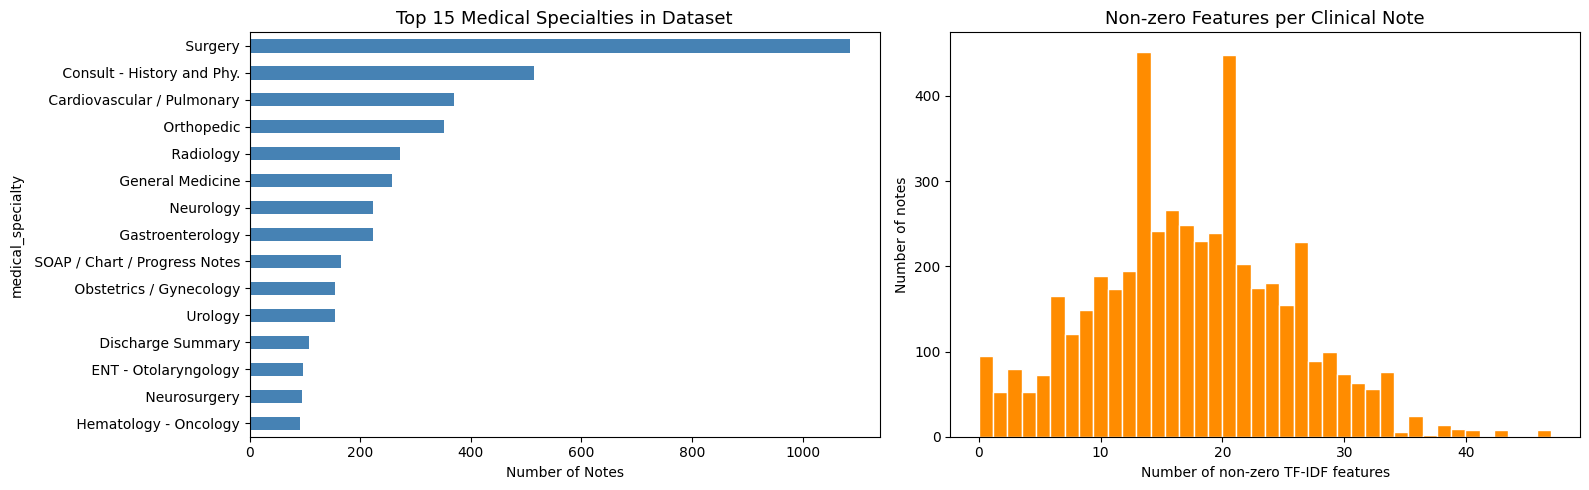

Sparsity stats:
  Avg non-zero features per note: 17.4 / 500
  Matrix sparsity: 96.5%


In [16]:
import matplotlib.pyplot as plt

# ── 1. Dataset distribution across specialties ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

specialty_counts = df_valid['medical_specialty'].value_counts().head(15)
specialty_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Medical Specialties in Dataset', fontsize=13)
axes[0].set_xlabel('Number of Notes')
axes[0].invert_yaxis()

# ── 2. Sparsity per note ──────────────────────────────────────────────────────
non_zero_per_row = (X_dense > 0).sum(axis=1)
axes[1].hist(non_zero_per_row, bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Non-zero Features per Clinical Note', fontsize=13)
axes[1].set_xlabel('Number of non-zero TF-IDF features')
axes[1].set_ylabel('Number of notes')

plt.tight_layout()
plt.savefig("/kaggle/working/pipeline_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Sparsity stats:")
print(f"  Avg non-zero features per note: {non_zero_per_row.mean():.1f} / {MAX_FEATURES}")
print(f"  Matrix sparsity: {100*(X_dense == 0).mean():.1f}%")

In [17]:
# ── 3. Negation rate ──────────────────────────────────────────────────────────
# Count how many features are NEG_ (negated) vs. positive
neg_features = [f for f in feature_names if f.startswith('NEG_')]
pos_features = [f for f in feature_names if not f.startswith('NEG_')]

print(f"Negation breakdown in final feature set:")
print(f"  Positive medical entity features: {len(pos_features)} ({100*len(pos_features)/len(feature_names):.1f}%)")
print(f"  Negated medical entity features:  {len(neg_features)} ({100*len(neg_features)/len(feature_names):.1f}%)")

if neg_features:
    print(f"\nSample negated features: {neg_features[:10]}")

print("\nPipeline complete. Files ready for handover:")
print("  features.csv       → Khansa (Member 1) — FCM input")
print("  feature_names.csv  → Zain   (Member 3) — cluster interpretation")
print("  specialty_labels.csv → Khansa (Member 1) — domain-guided init seeds")

Negation breakdown in final feature set:
  Positive medical entity features: 500 (100.0%)
  Negated medical entity features:  0 (0.0%)

Pipeline complete. Files ready for handover:
  features.csv       → Khansa (Member 1) — FCM input
  feature_names.csv  → Zain   (Member 3) — cluster interpretation
  specialty_labels.csv → Khansa (Member 1) — domain-guided init seeds


---
## Pipeline Summary

| Stage | Tool | Output |
|-------|------|--------|
| Load data | pandas | ~5,000 raw clinical notes |
| Clean text | regex | Stripped numeric noise |
| Medical NER | SciSpacy `en_core_sci_sm` | Entity spans per note |
| Negation detection | NegSpacy (clinical termset) | NEG_-prefixed entities |
| Vectorization | TF-IDF (sklearn) | Sparse N × 500 matrix |
| Normalization | L2 norm (built into TF-IDF) | Values in [0.0, 1.0] |
| **Export** | **pandas CSV** | **`features.csv` — headerless, pure numeric** |

### Files produced
- **`features.csv`** — main deliverable for Khansa's FCM
- **`feature_names.csv`** — feature index ↔ medical concept mapping for Zain
- **`specialty_labels.csv`** — medical specialty per note for domain-guided FCM init
- **`pipeline_analysis.png`** — plots for the Milestone 1 report